In [1]:
from src import DataPreprocessor

# Load the data
file_path = 'datasets/mall_customers.csv'
preprocessor = DataPreprocessor(file_path)
df = preprocessor.load_data()
head, info = preprocessor.inspect_data()

print("Data Head:")
print(head)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
Data Head:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


#### Παρατηρούμε:
    Έχουμε μικρό dataset (200 εγγραφές).Θα πρέπει να το έχουμε υπ'όψη γιατί θα επηρεάσει την εγκυρότητα των μοντέλων
    Δεν χρειάζεται να ελέγξουμε για null values.
#### Θα εξαλείψουμε τυχόν περίεργες τιμές και outliers, εστιάζοντας στις στήλες Annual Income και Spending Score

Original Row Count: 200
Rows Removed: 2
Current Row Count: 198
Outliers were detected and removed.


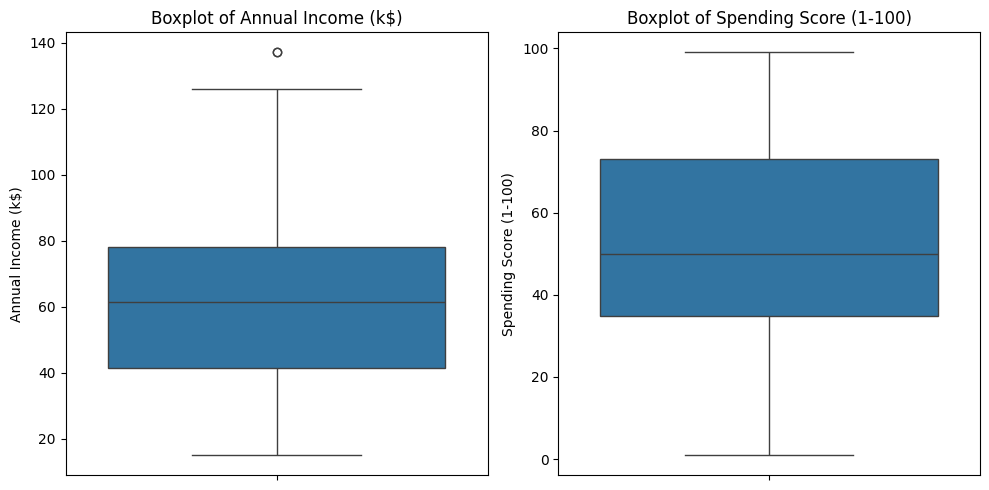

In [2]:
# Columns to check
cols_to_check = ['Annual Income (k$)', 'Spending Score (1-100)']

# 1. Visualize first (to see if there are "crazy" outliers)
preprocessor.plot_boxplots(cols_to_check)

# 2. Remove outliers
df_clean, removed_count = preprocessor.remove_outliers(cols_to_check)

print(f"Original Row Count: {200}") # We know it's 200 from previous step
print(f"Rows Removed: {removed_count}")
print(f"Current Row Count: {len(df_clean)}")

# Check if any were removed and from which column roughly (by inspecting bounds if needed, but count is sufficient for now)
if removed_count > 0:
    print("Outliers were detected and removed.")
else:
    print("No outliers detected based on 1.5 IQR threshold.")

#### Παρατηρούμε πως διαγράφηκαν 2 εγγραφές.
    Τη μία απο αυτές την βλέπουμε και στο πρώτο boxplot. Πρόκειται για πολύ υψηλή τιμή  εισοδήματος.